In [50]:
import numpy as np
import matplotlib.pyplot as plt

In [51]:
def lj_potential(r, sigma, epsilon):
    return 4 * epsilon * ((sigma / r) ** 12 - (sigma / r) ** 6)

In [52]:
def compute_lj_force(r_vec, sigma, epsilon):
    r = np.linalg.norm(r_vec)
    if r == 0:
        return np.zeros_like(r_vec)
    force_magnitude = 24 * epsilon * (2 * (sigma**12) / (r**13) - (sigma**6) / (r**7))
    force_vector = force_magnitude * (r_vec / r)
    return force_vector

In [ ]:
np.arange(0, 10)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [ ]:
sigma = 1.0
epsilon = 1.0

a = 2 ** (1 / 6) * sigma  # 平衡距離
num_particles = 10
# initial_positions = np.array([0, a - 0.2, 2 * a])
initial_positions = np.arange(0, num_particles) * a
initial_positions[1] += 0.1  # 粒子2をわずかにずらす
initial_velocities = np.zeros(num_particles)
masses = np.ones(num_particles)
total_time = 10.0
num_steps = 10000
dt = total_time / num_steps
pos_T = np.zeros((num_steps, num_particles))
pos_T[0] = initial_positions
pos_T[1] = initial_positions + initial_velocities * dt
box = [0, num_particles * a]  # シミュレーションボックスの範囲
r_cutoff = 2.5 * sigma  # カットオフ距離

In [89]:
t = 1
r_vec = pos_T[t, 1] - pos_T[t, 0]
force_on_0 = compute_lj_force(r_vec, sigma, epsilon)
force_on_1 = -force_on_0
print("Force on particle 0 at step", t, ":", force_on_0)
print("Force on particle 1 at step", t, ":", force_on_1)

Force on particle 0 at step 1 : -2.357342349947273
Force on particle 1 at step 1 : 2.357342349947273


In [90]:
num_particles = pos_T.shape[1]
forces_traj = np.zeros((num_steps, num_particles))
L = box[1] - box[0]
for t in range(1, num_steps - 1):
    for i in range(num_particles):
        for j in range(i + 1, num_particles):
            r_vec = pos_T[t, i] - pos_T[t, j]
            if -L / 2 < r_vec <= L / 2:
                r_vec = r_vec
            elif r_vec > L / 2:
                r_vec = r_vec - L
            else:  # r_vec <= -L/2
                r_vec = r_vec + L
            force_ij = compute_lj_force(r_vec, sigma, epsilon)
            forces_traj[t, i] += force_ij
            forces_traj[t, j] -= force_ij

    for i in range(num_particles):
        acceleration = forces_traj[t, i] / masses[i]
        pos_T[t + 1, i] = 2 * pos_T[t, i] - pos_T[t - 1, i] + acceleration * dt**2
        pos_T[t + 1, i] = pos_T[t + 1, i] % L  # PBC適用

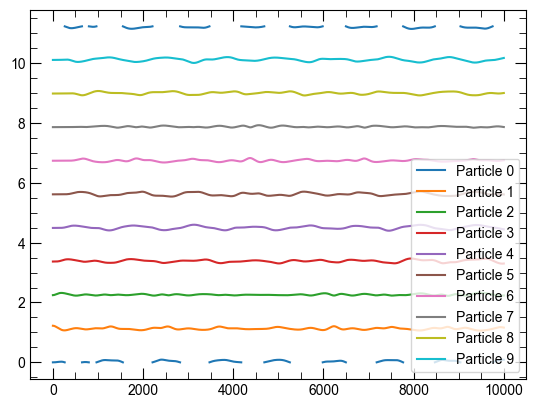

In [91]:
import numpy as np
import matplotlib.pyplot as plt

# 仮の例：pos_T は shape = (time_steps, num_particles)
# pos_T[t, i] = 粒子 i の位置
# ここではダミーデータを例示
np.random.seed(0)
timesteps = 10000

a = 1.0
threshold = 0.5  # 距離しきい値

fig, ax = plt.subplots()

for i in range(num_particles):
    pos = pos_T[:, i]

    # 隣接するフレーム間の変化量
    diff = np.abs(np.diff(pos, prepend=pos[0]))

    # 大きく動いた箇所をNaNにして線を切る
    pos_masked = pos.copy()
    pos_masked[diff > threshold] = np.nan

    ax.plot(pos_masked, label=f"Particle {i}")

# ax.set_ylim(-0.1, 3 * a)
ax.legend()
plt.show()

Text(0, 0.5, 'Force')

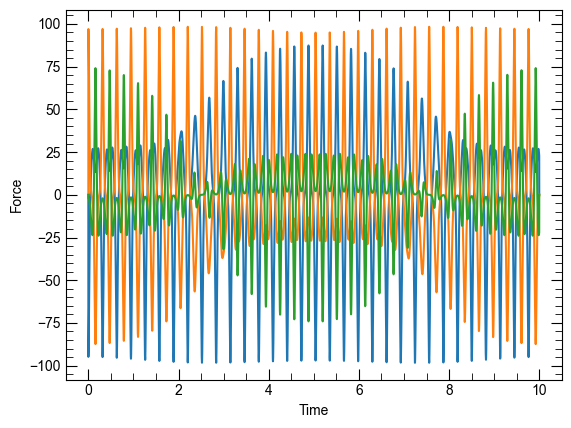

In [58]:
# plot forces over time
fig, ax = plt.subplots()
time_array = np.arange(num_steps) * dt
for i in range(num_particles):
    ax.plot(time_array, forces_traj[:, i], label=f"Force on Particle {i}")
ax.set_xlabel("Time")
ax.set_ylabel("Force")